In [1]:
import numpy as np
import pandas as pd
import os 
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

# Set up plotting style
plt.rcParams.update({'font.size': 12})
sns.set_style("whitegrid")

In [2]:
# Configuration for paw speed
base_path = "/media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/results"
eid = "5c0c560e-9e1f-45e9-b66e-e4ee7855be84"  # Updated to the session with paw speed data
target = "lightning-pose-right-pawR-speed"  # The paw speed target we decoded
# model = "linear"
model = "reduced_rank"

results_path = f"{base_path}/{eid}/{target}/{model}/all/{eid}.npy"
print(f"Loading results from: {results_path}")

Loading results from: /media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/results/5c0c560e-9e1f-45e9-b66e-e4ee7855be84/lightning-pose-right-pawR-speed/reduced_rank/all/5c0c560e-9e1f-45e9-b66e-e4ee7855be84.npy


In [3]:
# Load the paw speed data
data = np.load(results_path, allow_pickle=True).item()
print(f"Available keys: {data.keys()}")

# Extract data - should be in (n_trials, 100) shape = n_trials × 100 time bins
test_y = data['test_y']      # Ground truth paw speed
test_pred = data['test_pred']  # Predicted paw speed
test_metric = data['test_metric']  # Performance metric (correlation)

print(f"Data shapes: test_y={test_y.shape}, test_pred={test_pred.shape}")
print(f"Pearson correlation: {test_metric:.3f}")

Available keys: dict_keys(['test_metric', 'test_pred', 'test_y', 'test_prob'])
Data shapes: test_y=(63, 100), test_pred=(63, 100)
Pearson correlation: -42.105


In [4]:
# Flatten the data to get continuous time series across all test trials
y_flattened = test_y.flatten()      # Ground truth as continuous trace
pred_flattened = test_pred.flatten()  # Predictions as continuous trace

print(f"Flattened shapes: {y_flattened.shape}, {pred_flattened.shape}")
print(f"Total time points: {len(y_flattened)}")

# Calculate additional performance metrics
from sklearn.metrics import r2_score, mean_squared_error
correlation = np.corrcoef(y_flattened, pred_flattened)[0, 1]
r2 = r2_score(y_flattened, pred_flattened)
mse = mean_squared_error(y_flattened, pred_flattened)


Flattened shapes: (6300,), (6300,)
Total time points: 6300


In [5]:
print(f"Time bins per trial: {data['test_y'].shape[1]}")
print(f"Total trials: {data['test_y'].shape[0]}") 
print(f"Sampling rate: {1/0.02} Hz")  # 50 Hz
print(f"Total duration: {data['test_y'].shape[1] * 0.02} seconds")

Time bins per trial: 100
Total trials: 63
Sampling rate: 50.0 Hz
Total duration: 2.0 seconds


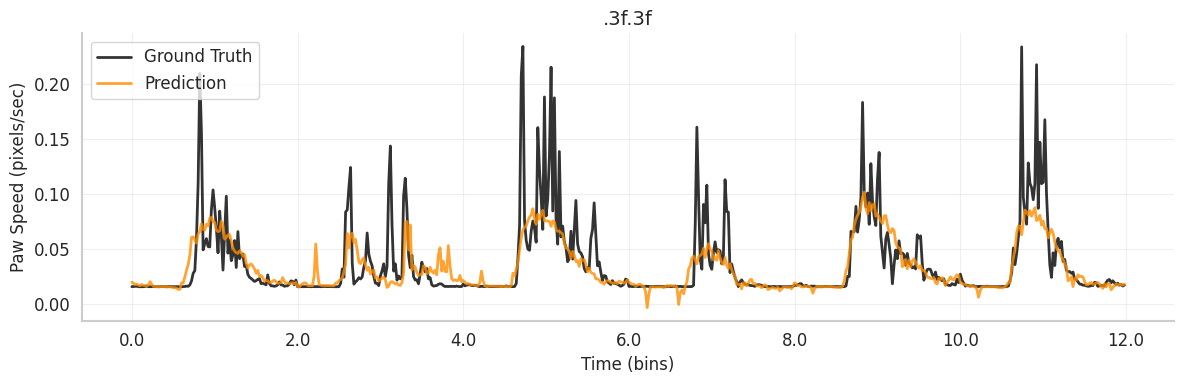

In [6]:
# Plot the continuous paw speed traces
start_time = 0
end_time = min(600, len(y_flattened))  # Show first 600 time points

fig, ax = plt.subplots(1, 1, figsize=(12, 4))

# Plot ground truth (black line, thicker)
ax.plot(y_flattened[start_time:end_time], color="black", linewidth=2, label="Ground Truth", alpha=0.8)

# Plot predictions (use a different color for paw speed)
ax.plot(pred_flattened[start_time:end_time], color="darkorange", linewidth=2, label="Prediction", alpha=0.8)

# Formatting
ax.set_ylabel("Paw Speed (pixels/sec)", fontsize=12)
ax.set_xlabel("Time (bins)", fontsize=12)
ax.set_title(".3f"".3f", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', width=1.5, length=5, labelsize=12)

# we have that Bin 0 is 0 seconds, Bin 100 is 2 seconds, Bin 200 is 4 seconds, etc.
# Convert x-axis to time in seconds (assuming 50Hz = 0.02s per bin)
xticks = [0, 100, 200, 300, 400, 500, 600]
xticklabels = [f"{x * 0.02:.1f}" for x in xticks]  # ✅ Convert bins to seconds
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)

plt.tight_layout()
# plt.savefig('paw_speed_traces.png', dpi=400, bbox_inches='tight')
plt.show()

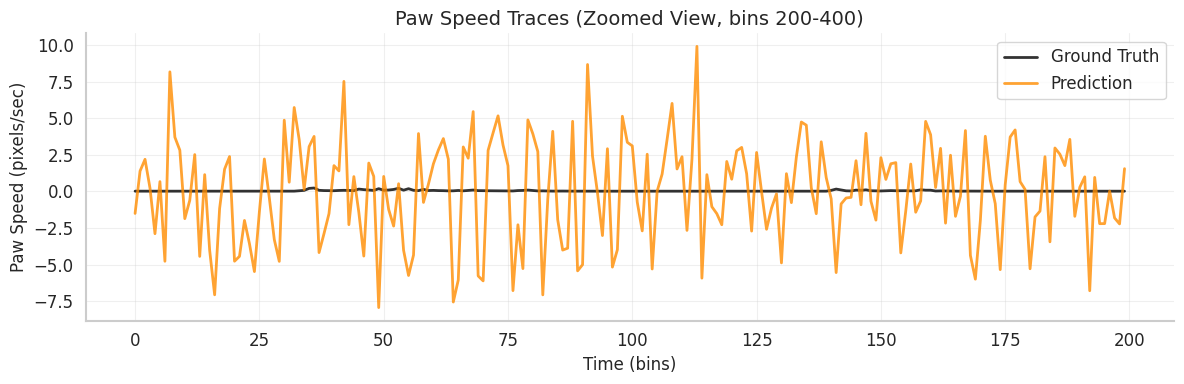

In [12]:
# Plot a zoomed-in view
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
start_zoom = 200  # Start at bin 200
end_zoom = 400    # End at bin 400

ax.plot(y_flattened[start_zoom:end_zoom], color="black", linewidth=2, label="Ground Truth", alpha=0.8)
ax.plot(pred_flattened[start_zoom:end_zoom], color="darkorange", linewidth=2, label="Prediction", alpha=0.8)

ax.set_ylabel("Paw Speed (pixels/sec)", fontsize=12)
ax.set_xlabel("Time (bins)", fontsize=12)
ax.set_title(f"Paw Speed Traces (Zoomed View, bins {start_zoom}-{end_zoom})", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', width=1.5, length=5, labelsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# Additional analysis: Plot distribution of speeds
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of ground truth speeds
axes[0].hist(y_flattened, bins=50, alpha=0.7, color='black', density=True)
axes[0].set_title('Ground Truth Speed Distribution')
axes[0].set_xlabel('Paw Speed (pixels/sec)')
axes[0].set_ylabel('Density')

# Distribution of predicted speeds
axes[1].hist(pred_flattened, bins=50, alpha=0.7, color='darkorange', density=True)
axes[1].set_title('Predicted Speed Distribution')
axes[1].set_xlabel('Paw Speed (pixels/sec)')
axes[1].set_ylabel('Density')

# Scatter plot: predicted vs ground truth
axes[2].scatter(y_flattened, pred_flattened, alpha=0.1, s=1, color='darkorange')
axes[2].plot([y_flattened.min(), y_flattened.max()], [y_flattened.min(), y_flattened.max()], 
             'k--', linewidth=2, alpha=0.7)
axes[2].set_title('Predicted vs Ground Truth')
axes[2].set_xlabel('Ground Truth Speed (pixels/sec)')
axes[2].set_ylabel('Predicted Speed (pixels/sec)')

plt.tight_layout()
plt.savefig('paw_speed_analysis.png', dpi=400, bbox_inches='tight')
plt.show()

In [41]:
# Load the dataset to check sizes
from datasets import load_from_disk
import os

# Path to your dataset
dataset_path = "/media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/ibl_aligned/5c0c560e-9e1f-45e9-b66e-e4ee7855be84"

if os.path.exists(dataset_path):
    dataset = load_from_disk(dataset_path)
    
    print("Dataset splits and sizes:")
    for split_name in ['train', 'val', 'test']:
        if split_name in dataset:
            print(f"{split_name}: {len(dataset[split_name])} trials")
else:
    print("Dataset path not found")

Dataset splits and sizes:
train: 220 trials
val: 32 trials
test: 63 trials
